##### ARTI 560 - Computer Vision  
## Image Classification using Convolutional Neural Networks (CNNs) - Exercise 

### Objective

In this exercise, you will:

1. **Load the Fashion MNIST dataset** from the [Keras dataset](https://keras.io/api/datasets/) website.
2. **Preprocess the data** for training.
3. **Build your own CNN architecture** and evaluate the model.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.utils import to_categorical



2026-02-12 15:33:04.402067: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [4]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
# Number of unique classes
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

Number of classes: 10


In [6]:
# Define class names for easy reference
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]



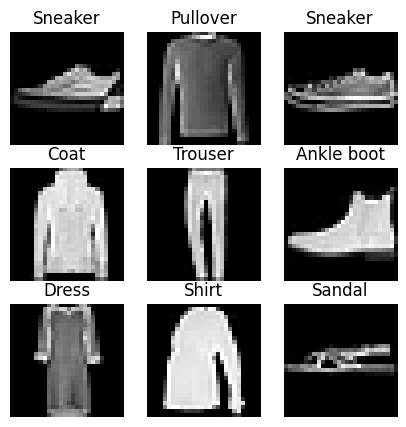

In [7]:
# Plot a 3x3 grid of random images from the dataset with their labels
plt.figure(figsize=(5, 5))
for i in range(9):
    # Pick random index
    idx = np.random.randint(0, len(x_train))
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[y_train[idx]])
    plt.axis('off')


plt.show()

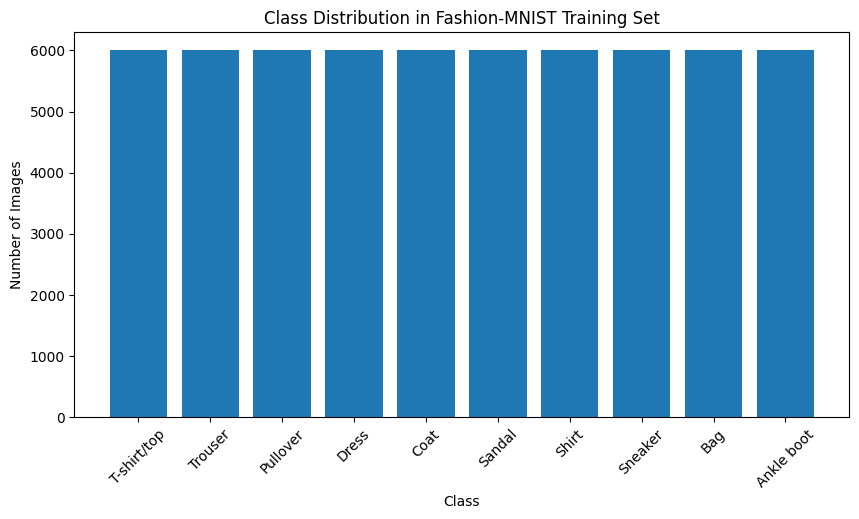

In [8]:
# Count occurrences of each class
class_counts = np.bincount(y_train)

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)

plt.title("Class Distribution in Fashion-MNIST Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


### Build your Image Classification Model
Note: Don't use one hot encoding and use sparse_categorical_crossentropy for loss

In [9]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")  # 10 classes
])

# Compile ( sparse_categorical_crossentropy)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Epoch 1/10
844/844 [==============================] - 11s 12ms/step - loss: 0.5460 - accuracy: 0.8051 - val_loss: 0.3587 - val_accuracy: 0.8712
Epoch 2/10
844/844 [==============================] - 10s 11ms/step - loss: 0.3583 - accuracy: 0.8700 - val_loss: 0.3182 - val_accuracy: 0.8862
Epoch 3/10
844/844 [==============================] - 10s 11ms/step - loss: 0.3078 - accuracy: 0.8886 - val_loss: 0.2878 - val_accuracy: 0.8942
Epoch 4/10
844/844 [==============================] - 10s 11ms/step - loss: 0.2806 - accuracy: 0.8968 - val_loss: 0.2581 - val_accuracy: 0.9035
Epoch 5/10
844/844 [==============================] - 10s 11ms/step - loss: 0.2576 - accuracy: 0.9048 - val_loss: 0.2580 - val_accuracy: 0.9045
Epoch 6/10
844/844 [==============================] - 10s 11ms/step - loss: 0.2379 - accuracy: 0.9118 - val_loss: 0.2486 - val_accuracy: 0.9070
Epoch 7/10
844/844 [==============================] - 10s 11ms/step - loss: 0.2181 - accuracy: 0.9197 - val_loss: 0.2385 - val_accuracy: